In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found exi

In [2]:
import yaml

# Load original data.yaml
yaml_path = "/kaggle/input/forestfire/data.yaml"

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Fix the paths (use absolute paths for Kaggle)
data['train'] = '/kaggle/input/forestfire/train'
data['val'] = '/kaggle/input/forestfire/valid'
# Optional: test path if you want to evaluate
data['test'] = '/kaggle/input/forestfire/test'

# Save the new YAML file to working directory
new_yaml_path = '/kaggle/working/data.yaml'

with open(new_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("Updated data.yaml saved at:", new_yaml_path)


Updated data.yaml saved at: /kaggle/working/data.yaml


In [3]:
import yaml

yaml_path = "/kaggle/working/data.yaml"

# Open and load the YAML file
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

# Print contents
print("YAML contents:")
print(data)

YAML contents:
{'names': ['fire'], 'nc': 1, 'roboflow': {'license': 'CC BY 4.0', 'project': 'wildfire-yh86l', 'url': 'https://universe.roboflow.com/mini-z0ruz/wildfire-yh86l/dataset/2', 'version': 2, 'workspace': 'mini-z0ruz'}, 'test': '/kaggle/input/forestfire/test', 'train': '/kaggle/input/forestfire/train', 'val': '/kaggle/input/forestfire/valid'}


In [4]:
from ultralytics import YOLO
from IPython.display import Image


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
!yolo task=detect mode=train data=/kaggle/working/data.yaml model="yolov8s.pt" epochs=100 imgsz=640

100%|███████████████████████████████████████| 21.5M/21.5M [00:00<00:00, 176MB/s]
Ultralytics 8.3.144 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/2019-09-13-00_00_2019-09-13-23_59_Sentinel-2_L2A_Wildfires.jpg: 288x640 1 fire, 39.5ms
Speed: 1.7ms preprocess, 39.5ms inference, 185.8ms postprocess per image at shape (1, 3, 288, 640)


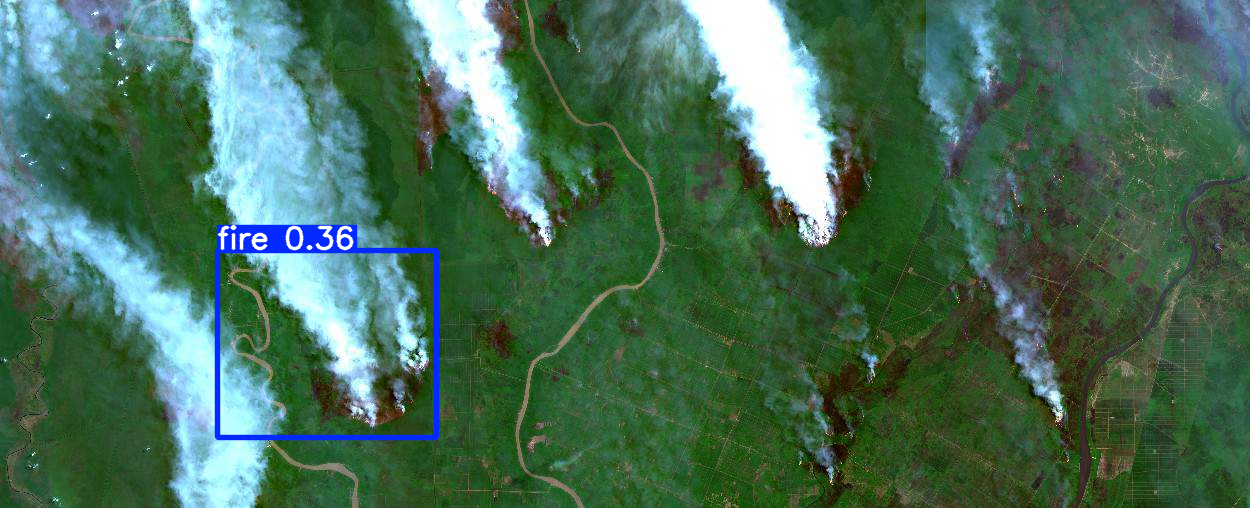


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images (1).jpg: 448x640 (no detections), 40.6ms
Speed: 1.6ms preprocess, 40.6ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)


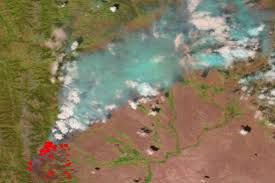


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images (2).jpg: 384x640 2 fires, 38.3ms
Speed: 1.4ms preprocess, 38.3ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)


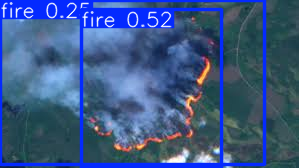


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images.jpg: 448x640 (no detections), 13.6ms
Speed: 1.4ms preprocess, 13.6ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


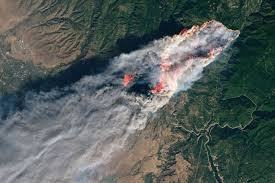

In [6]:
from ultralytics import YOLO

# Load the trained model
# IT IS STORED IN THE FOLLOWING VALIDATION FOLDER NAMED Validating runs/detect/train/weights/best.pt.
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

results = model("/kaggle/input/forest-fireimg/fOREST-fire/2019-09-13-00_00_2019-09-13-23_59_Sentinel-2_L2A_Wildfires.jpg")
results[0].show()

results = model("/kaggle/input/forest-fireimg/fOREST-fire/images (1).jpg")
results[0].show()

results = model("/kaggle/input/forest-fireimg/fOREST-fire/images (2).jpg")
results[0].show()

results = model("/kaggle/input/forest-fireimg/fOREST-fire/images.jpg")
results[0].show()

In [7]:
import pandas as pd
df = pd.read_csv('/kaggle/working/runs/detect/train/results.csv')
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,54.6021,1.82940,2.67093,1.85608,0.09605,0.17606,0.05101,0.01410,2.50218,4.01896,3.18205,0.000663,0.000663,0.000663
1,2,108.5680,1.89233,2.37182,1.91268,0.19251,0.16901,0.09444,0.02877,2.32283,3.24891,2.76133,0.001317,0.001317,0.001317
2,3,166.7300,1.84933,2.33875,1.88668,0.28236,0.38653,0.25321,0.09633,2.04270,2.57966,2.35897,0.001957,0.001957,0.001957
3,4,223.4530,1.83084,2.27302,1.86067,0.26575,0.36268,0.24246,0.09350,2.06826,2.58478,2.31737,0.001941,0.001941,0.001941
4,5,280.7410,1.77380,2.21195,1.80567,0.21905,0.23592,0.14436,0.06226,1.97402,2.78876,2.29256,0.001921,0.001921,0.001921


F1 Curve:


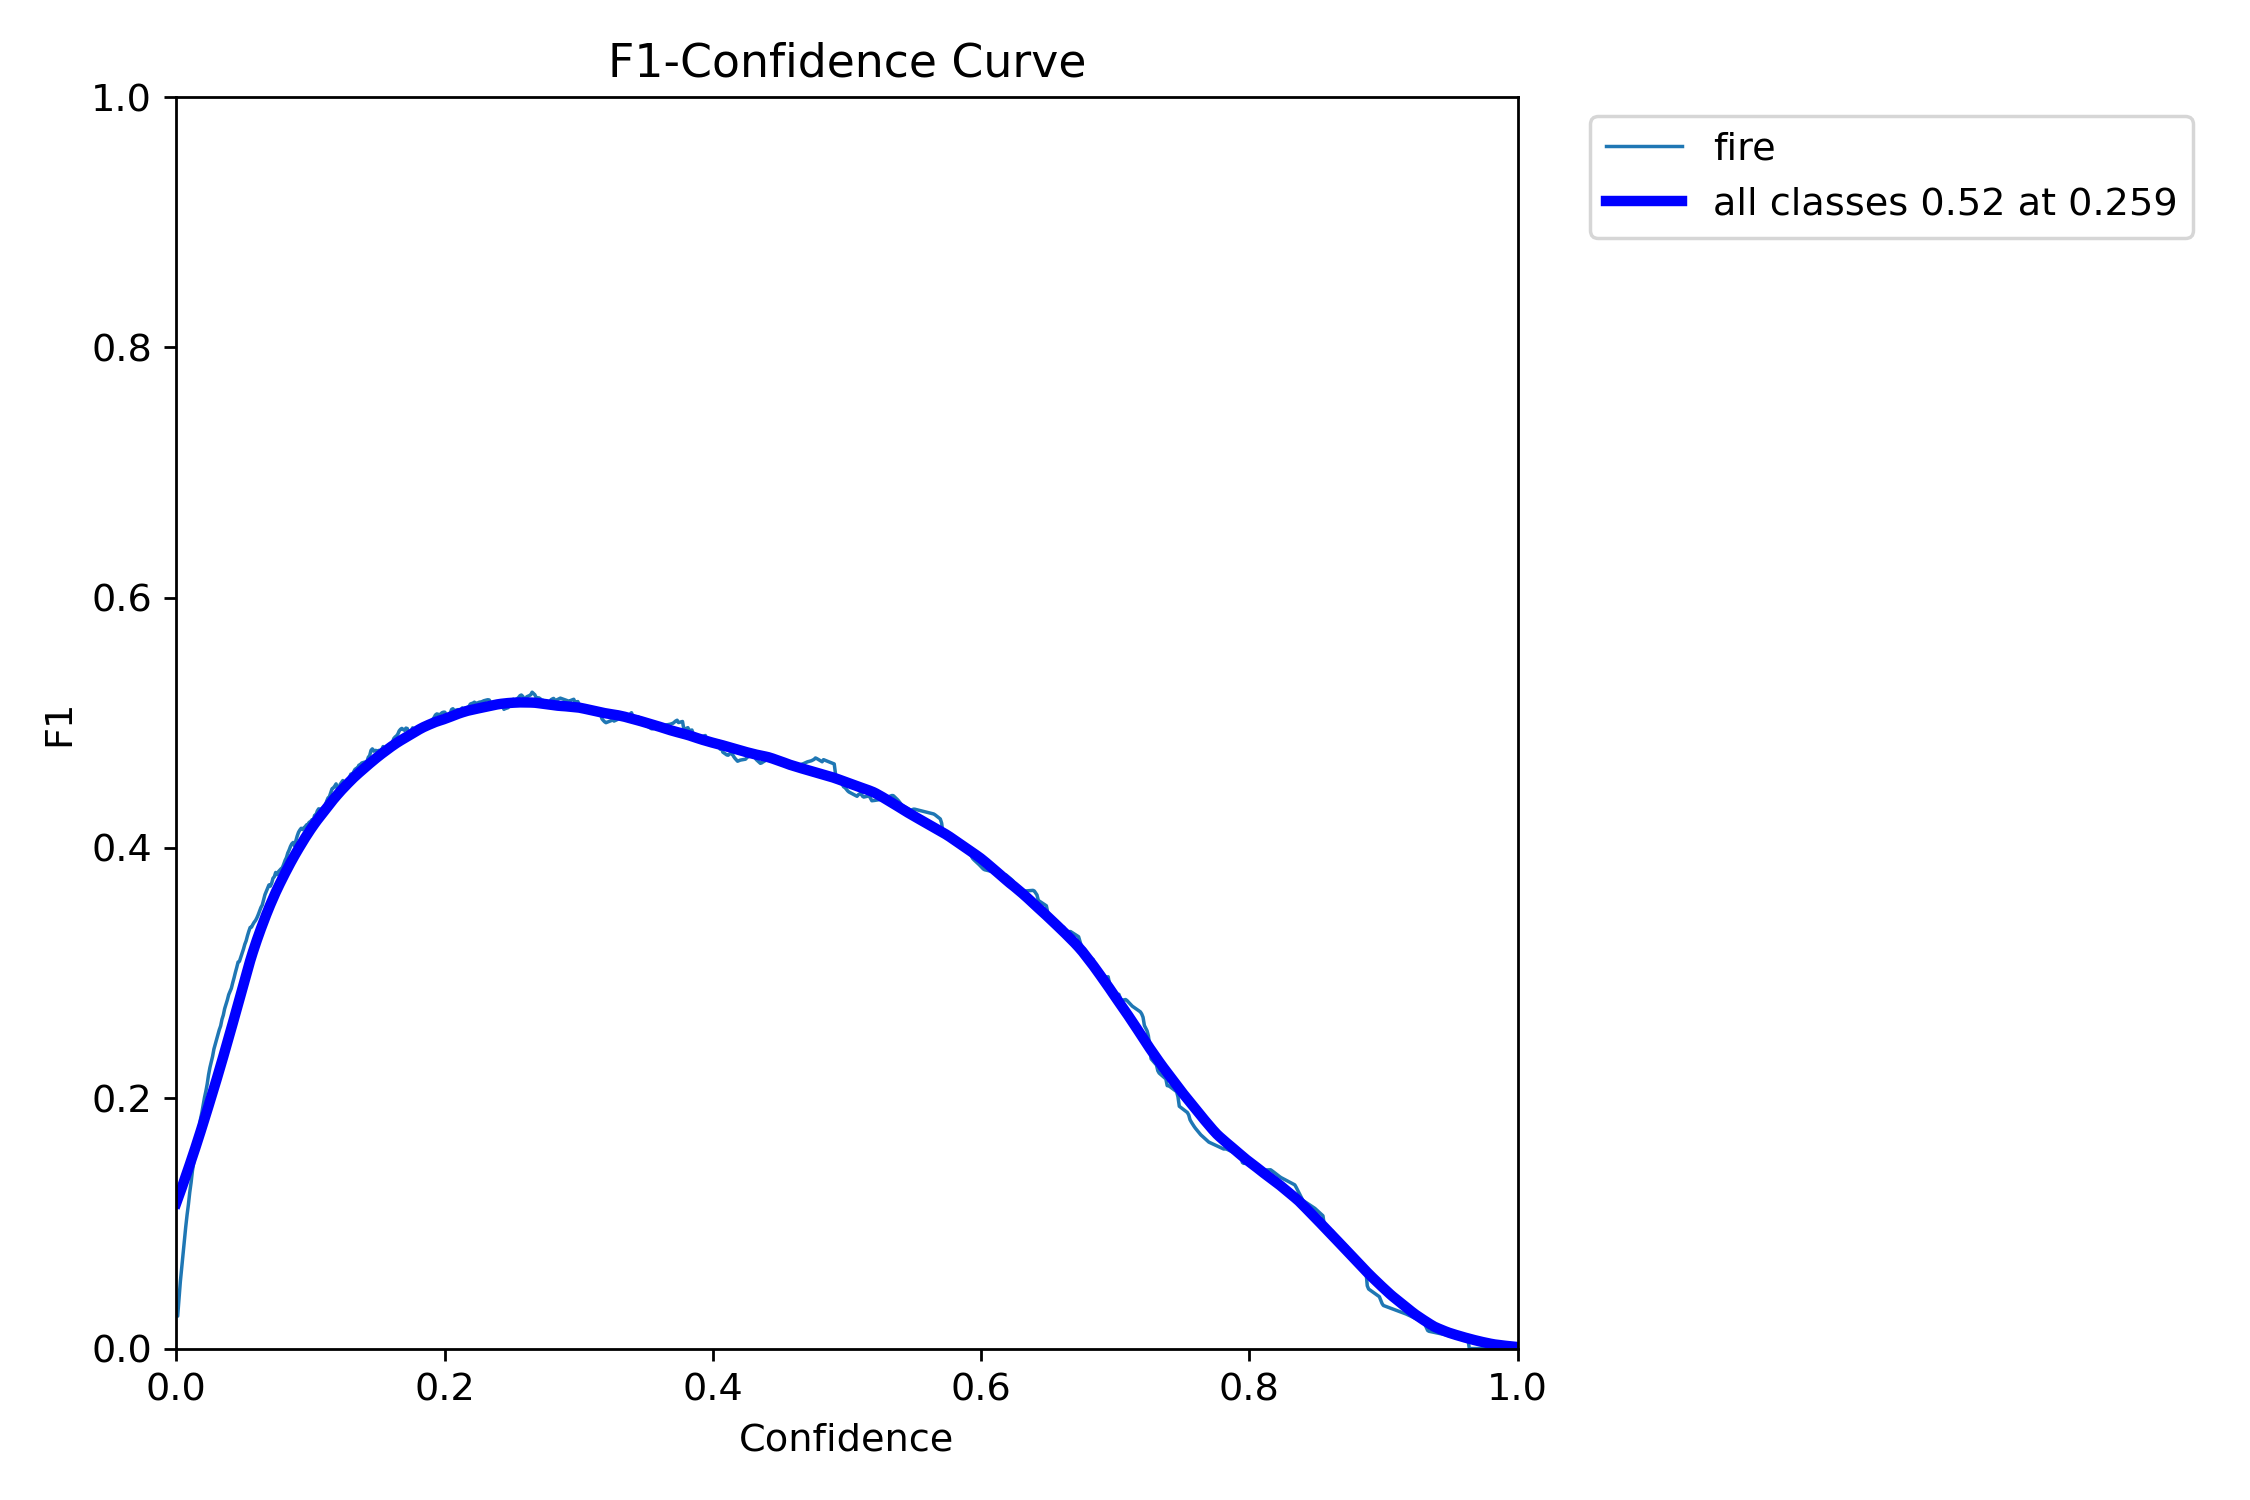

In [8]:
print("F1 Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/F1_curve.png'))

Precision-Recall Curve:


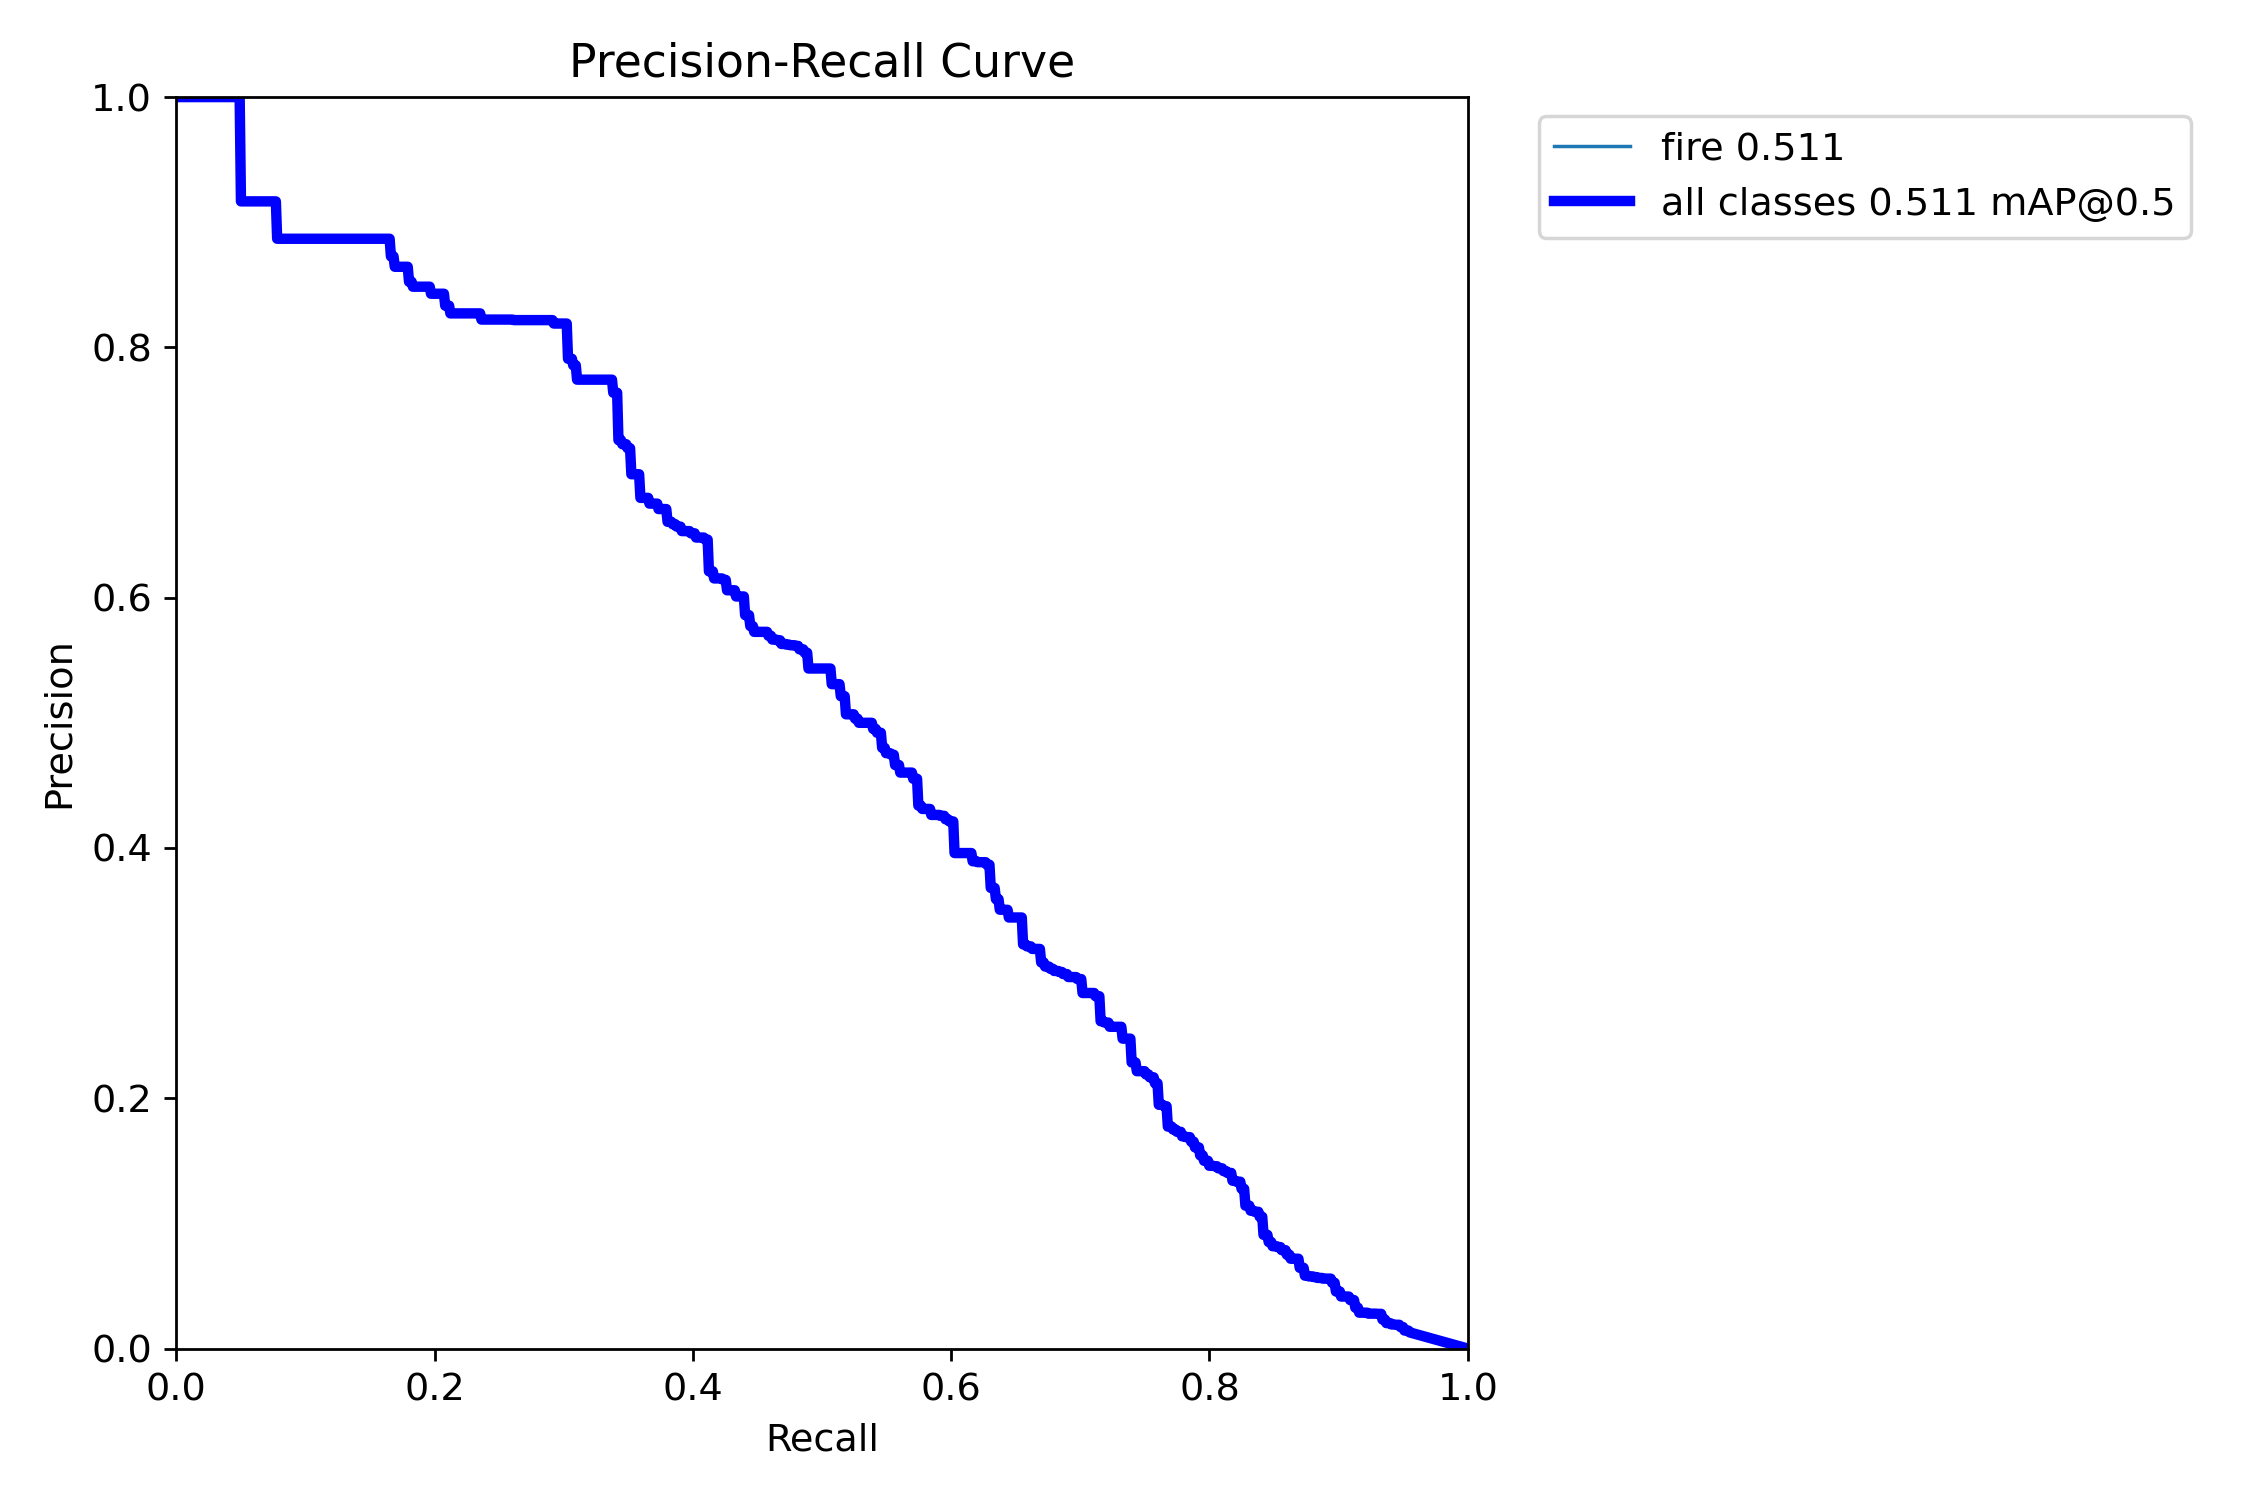

In [9]:
print("Precision-Recall Curve:")
display(Image(filename='/kaggle/working/runs/detect/train/PR_curve.png'))

Confusion Matrix:


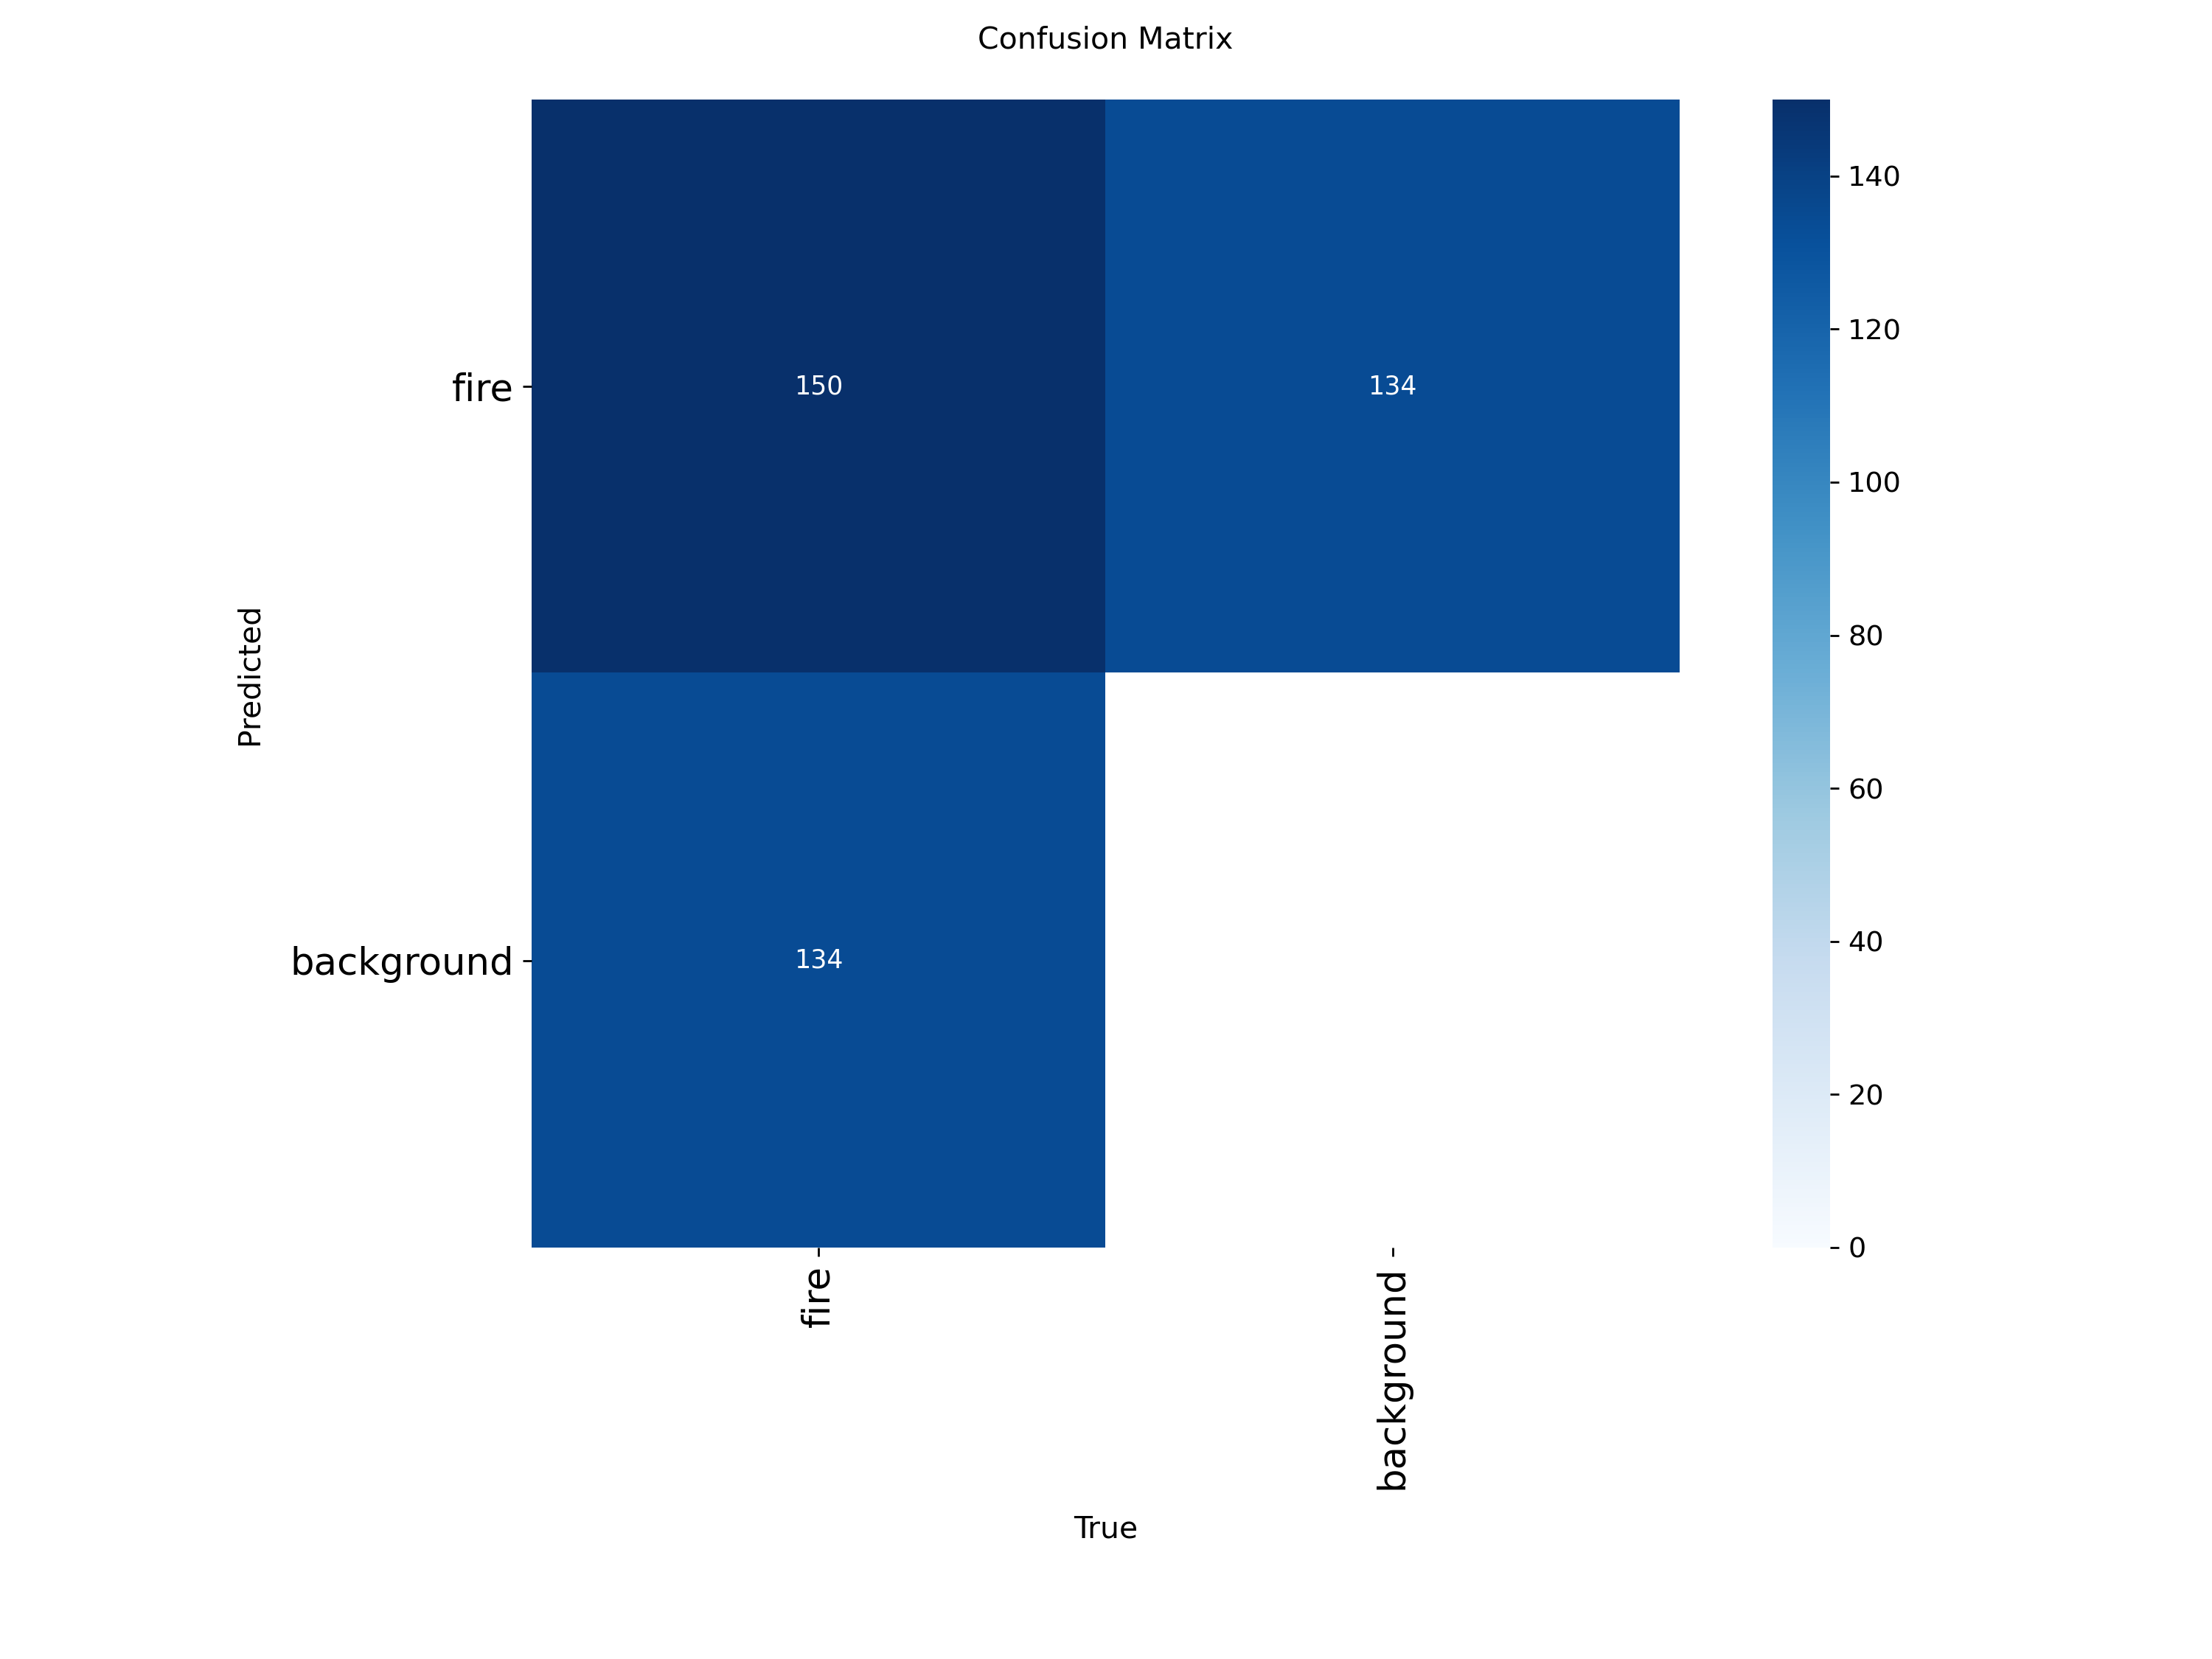

In [10]:
print("Confusion Matrix:")
display(Image(filename='/kaggle/working/runs/detect/train/confusion_matrix.png'))

Training Results:


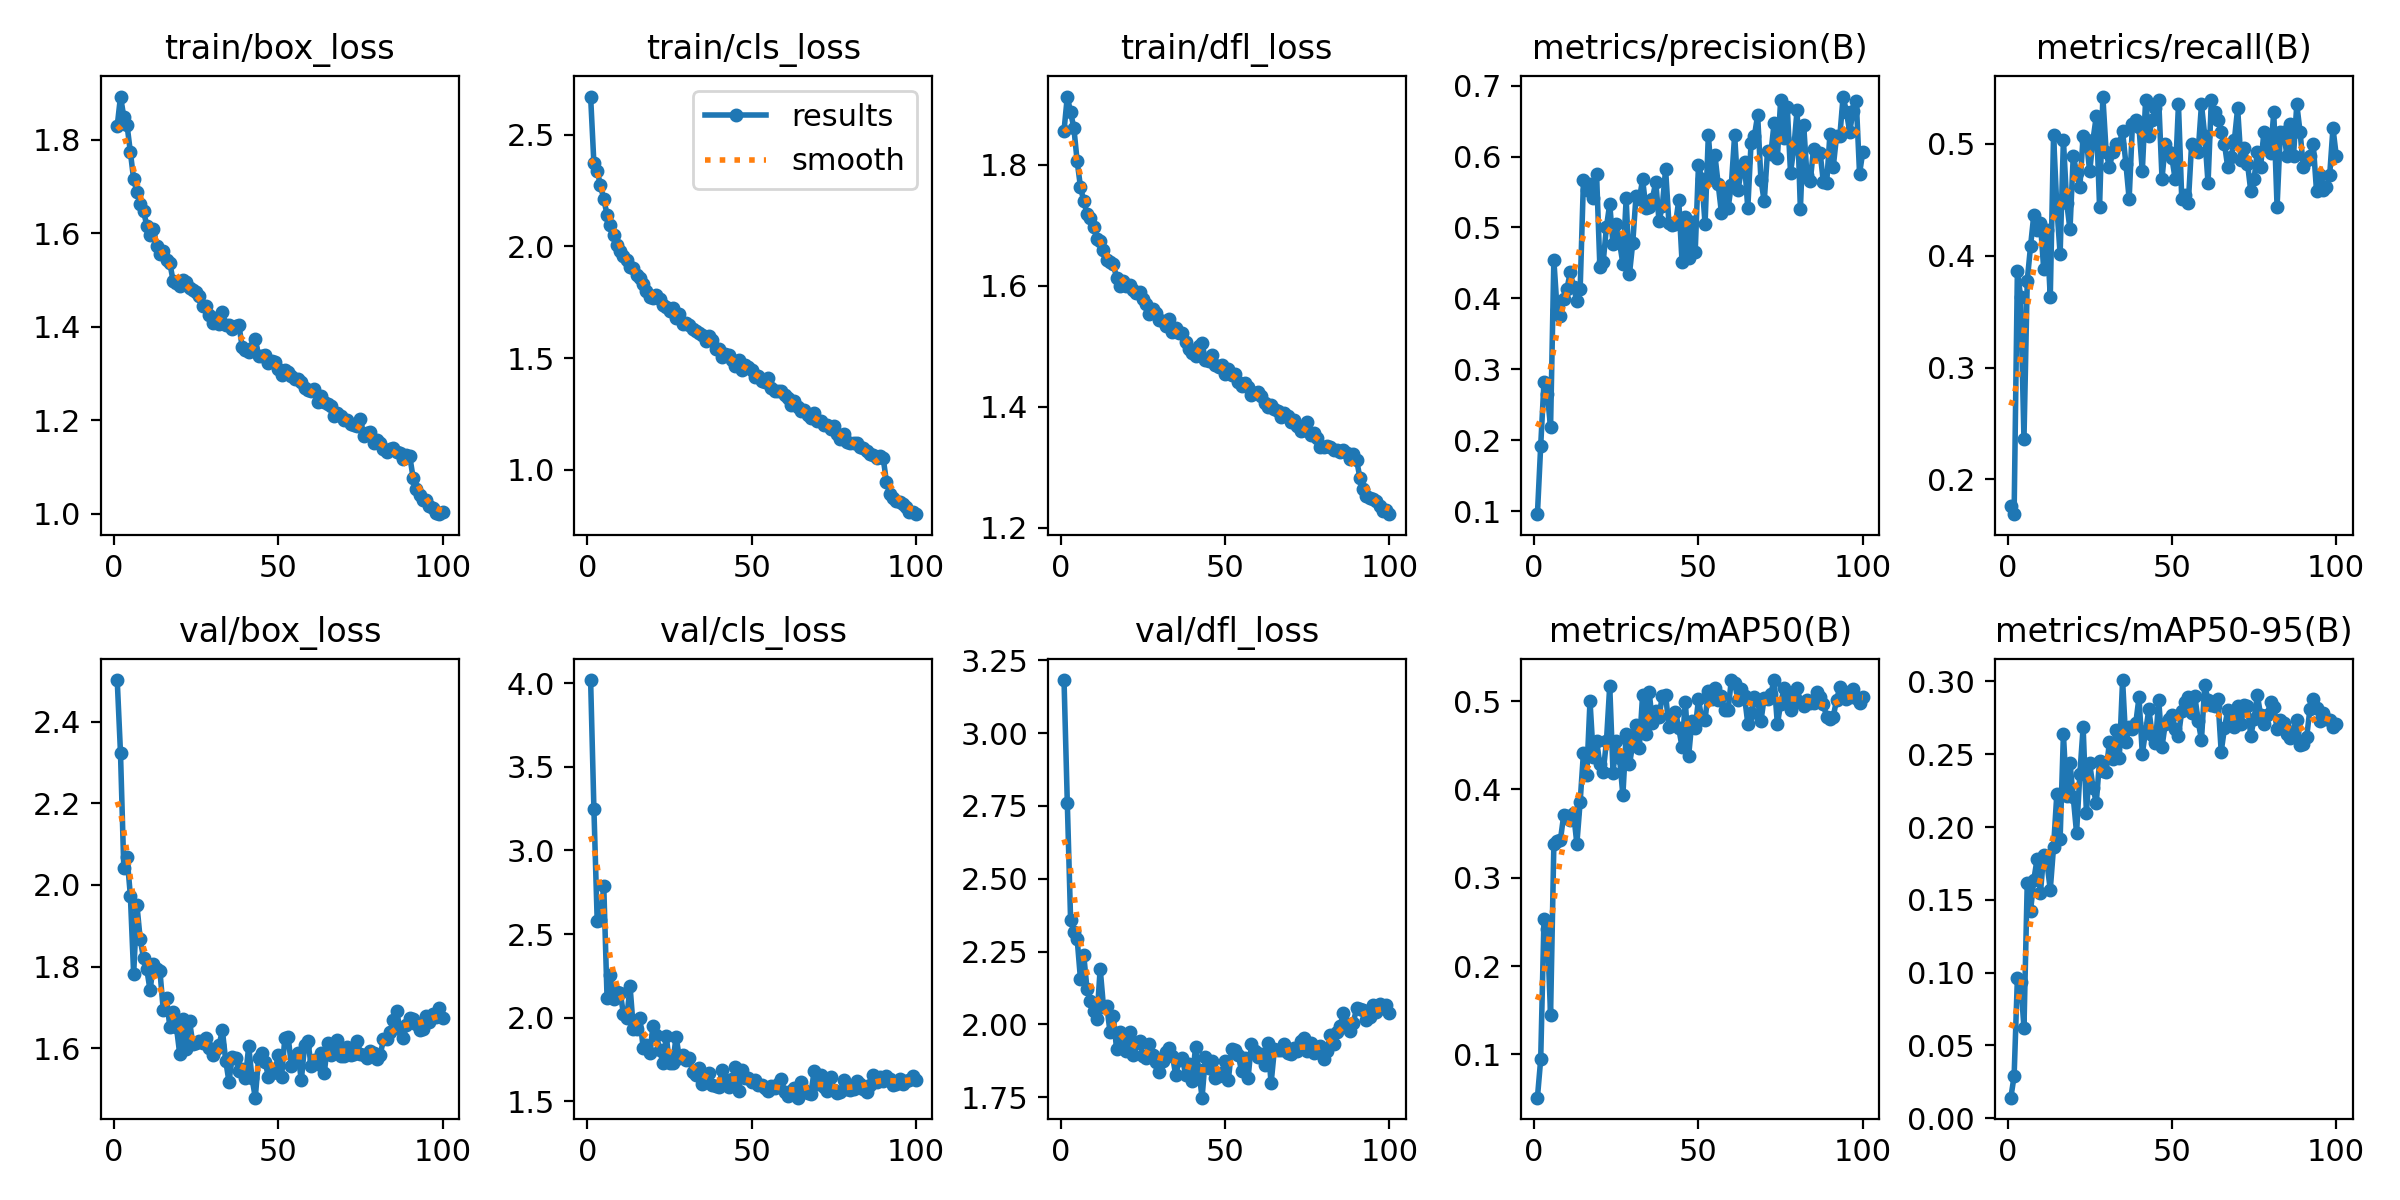

In [11]:
print("Training Results:")
display(Image(filename='/kaggle/working/runs/detect/train/results.png'))

In [12]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fireimg/fOREST-fire/2019-09-13-00_00_2019-09-13-23_59_Sentinel-2_L2A_Wildfires.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/2019-09-13-00_00_2019-09-13-23_59_Sentinel-2_L2A_Wildfires.jpg: 288x640 1 fire, 11.1ms
Speed: 1.5ms preprocess, 11.1ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 640)
Latency: 212.03 ms


In [13]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fireimg/fOREST-fire/images (1).jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images (1).jpg: 448x640 (no detections), 13.6ms
Speed: 1.8ms preprocess, 13.6ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Latency: 220.97 ms


In [14]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fireimg/fOREST-fire/images (2).jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images (2).jpg: 384x640 2 fires, 11.2ms
Speed: 1.4ms preprocess, 11.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Latency: 197.16 ms


In [15]:
import time
import torch

# Example: Load YOLOv5s model
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')
# Replace with your test image path
img = '/kaggle/input/forest-fireimg/fOREST-fire/images.jpg'

# Measure inference time
start = time.time()
results = model(img)
end = time.time()

print(f"Latency: {(end - start)*1000:.2f} ms")


image 1/1 /kaggle/input/forest-fireimg/fOREST-fire/images.jpg: 448x640 (no detections), 13.5ms
Speed: 1.5ms preprocess, 13.5ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Latency: 198.57 ms
